# Identifying Underserved Cuisine Markets Using Big Data
**Authors:** Wyatt Green & Mahad Arshad
**Course:** CSCI 3394 - Big Data & Machine Learning

### Project Overview
This notebook implements a site-selection algorithm using Apache Spark. We combine demographic data (Census) with restaurant supply data (OpenStreetMap) to identify market gaps.

**Key Steps:**
1.  **Data Ingestion & Cleaning:** Loading JSON/CSV data and handling null values.
2.  **Clustering (K-Means):** Segmenting zip codes into "Market Types" (e.g., Rural, High Income).
3.  **Regression (Random Forest):** Predicting the "expected" number of restaurants based on demographics.
4.  **Gap Analysis:** Calculating `Predicted - Actual` supply to find underserved areas.

In [1]:
from pyspark.sql import SparkSession
from sedona.register import SedonaRegistrator 

SPARK_MAJOR_VERSION = "4.0" 
SCALA_VERSION = "2.13"      
SEDONA_VERSION = "1.8.0"    

SEDONA_PACKAGE = f"org.apache.sedona:sedona-spark-shaded-{SPARK_MAJOR_VERSION}_{SCALA_VERSION}:{SEDONA_VERSION}"

print("Initializing Spark Session with Apache Sedona...")
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("Cuisine Gap Analysis")
    .config("spark.jars.packages", SEDONA_PACKAGE)
    .config("spark.sql.extensions", "org.apache.spark.sql.sedona.SedonaSparkSessionExtension")
    .getOrCreate()
)
SedonaRegistrator.registerAll(spark)
print("Spark Initialized.")

/var/folders/jp/gcgt3w155j34f571cdp8f_9r0000gn/T/ipykernel_32303/1708591591.py:2: DeprecationWarning: Importing from 'sedona.register' is deprecated. Please use 'sedona.spark.register.geo_registrator' instead.
  from sedona.register import SedonaRegistrator


Initializing Spark Session with Apache Sedona...


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/09 13:08:34 WARN Utils: Your hostname, MacBook-Pro-126.local, resolves to a loopback address: 127.0.0.1; using 10.100.146.133 instead (on interface en0)
25/12/09 13:08:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
:: loading settings :: url = jar:file:/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /Users/wg1911/.ivy2.5.2/cache
The jars for the packages stored in: /Users/wg1911/.ivy2.5.2/jars
org.apache.sedona#sedona-spark-shaded-4.0_2.13 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-42794c73-3f71-4779-882f-d83ed05b08c4;1.0
	confs: [default]
	found org.apache.sedona#sedona-spark-shaded-4.0_2.13;1.8.0 in central
:: resolution report :: resolve 45ms :: artifacts dl 1ms
	:: modules in use:
	org.apache.sedon

Spark Initialized.


In [2]:
import warnings
import logging

# Suppress Python warnings
warnings.filterwarnings('ignore')

# Suppress Spark logs (keep only ERRORs)
spark.sparkContext.setLogLevel("ERROR")

In [3]:
from pyspark.sql.types import StructType, StructField, StringType
from pyspark.sql.functions import from_json, col

# --- SCHEMA DEFINITION ---
fixed_osm_schema = StructType([
    StructField("category", StringType(), True),
    StructField("amenity", StringType(), True), 
    StructField("name", StringType(), True), 
    StructField("geometry_wkt", StringType(), True),
    StructField("feature_id", StringType(), True),
    StructField("zip_code", StringType(), True),
    StructField("addr:postcode", StringType(), True),
    StructField("cuisine", StringType(), True),
])

# Load OSM Data
OSM_df_raw = spark.read.text("data/flat_data.json").select(
    from_json(col("value"), fixed_osm_schema).alias("data")
).select("data.*")

# Load ZIP/Census Data
ZIP_df_raw = spark.read.option("header", "true") \
    .option("inferSchema", "false") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .csv("data/us_food.csv")

print(f"OSM Count: {OSM_df_raw.count()} | Census Count: {ZIP_df_raw.count()}")

OSM Count: 476641 | Census Count: 3222


In [4]:
from pyspark.sql.functions import coalesce, substring, trim, lpad, regexp_replace as F_regexp_replace

# 1. Filter and Clean OSM Zips
OSM_df_filtered = OSM_df_raw.filter((col("zip_code").isNotNull()) | (col("addr:postcode").isNotNull()))

OSM_df_temp = OSM_df_filtered.withColumn(
    "Combined_ZIP", coalesce(col("addr:postcode"), col("zip_code"))
).withColumn(
    "OSM_Join_Key", lpad(substring(trim(col("Combined_ZIP").cast("string")), 1, 5), 5, '0')
).filter(col("OSM_Join_Key") != '00000')

# 2. Clean Census FIPS
ZIP_df_temp = ZIP_df_raw.withColumn(
    "FIPS_Key", lpad(F_regexp_replace(trim(col("fips").cast("string")), "[^0-9]", ""), 5, '0')
)

OSM_df_temp.createOrReplaceTempView("OSM_temp_view")
ZIP_df_temp.createOrReplaceTempView("ZIP_county_view")
print("Keys standardized.")

Keys standardized.


In [5]:
# Load Crosswalk
CROSSWALK_df = spark.read.csv("data/zip_county_crosswalk.csv", header=True, inferSchema=True)

# Clean Crosswalk Keys
CROSSWALK_df = CROSSWALK_df.withColumn(
    "Xwalk_ZIP_Key", lpad(trim(col("ZIP").cast("string")), 5, '0')
).withColumn(
    "Xwalk_FIPS_Key", lpad(F_regexp_replace(trim(col("COUNTY").cast("string")), "[^0-9]", ""), 5, '0')
)

CROSSWALK_df.createOrReplaceTempView("Crosswalk_view")
print("Crosswalk Loaded.")

Crosswalk Loaded.


In [6]:
# Step 1: Join OSM to Crosswalk
join_query_step1 = """
    SELECT o.*, x.Xwalk_FIPS_Key, x.RES_RATIO
    FROM OSM_temp_view o
    LEFT OUTER JOIN Crosswalk_view x ON o.OSM_Join_Key = x.Xwalk_ZIP_Key
"""
df_mid_joined = spark.sql(join_query_step1).filter(col("Xwalk_FIPS_Key").isNotNull())
df_mid_joined.createOrReplaceTempView("Mid_Joined_view")

# Step 2: Join to Census Data
join_query_step2 = """
    SELECT m.*, z.*
    FROM Mid_Joined_view m
    INNER JOIN ZIP_county_view z ON m.Xwalk_FIPS_Key = z.FIPS_Key
"""
df_final_joined = spark.sql(join_query_step2)
print(f"Final Joined Count: {df_final_joined.count()}")

Final Joined Count: 539612


In [7]:
df_final_joined.show(10)

+--------+---------------+--------------------+--------------------+----------------+--------+-------------+-----------+------------+------------+--------------+--------------------+-----+----------+-------------------+-----+-------------------+------------------+------------------+----------------------------------+-----------+------------------+-------------+------------------+-------------------+-------------+----------------------+------------------+------------------+-------+----------+--------+----+---------+-------------------+-----------+--------+------------------+----------------+--------------------------+---------------+---------------------------------------------+------------------------+------------------+---------------+-----------------+------------------------+---------------------+------+---------------------+------+----------+-----------------+----------+----------------+-----------------+-----------------+------------------------+--------------------+------+-------

Initial EDA on Raw Joined Data Complete. Displaying visualizations now.


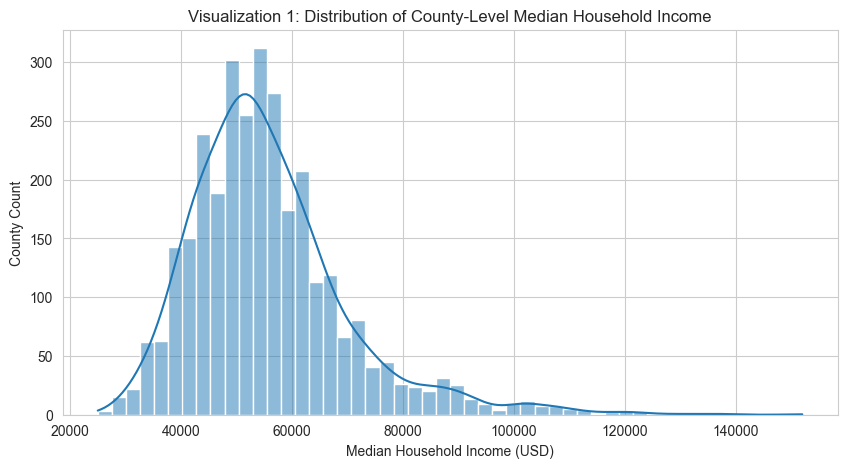

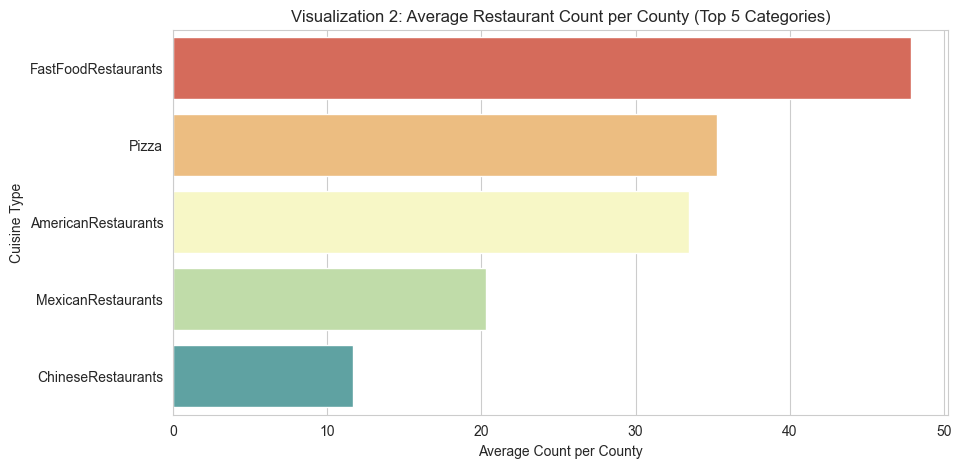

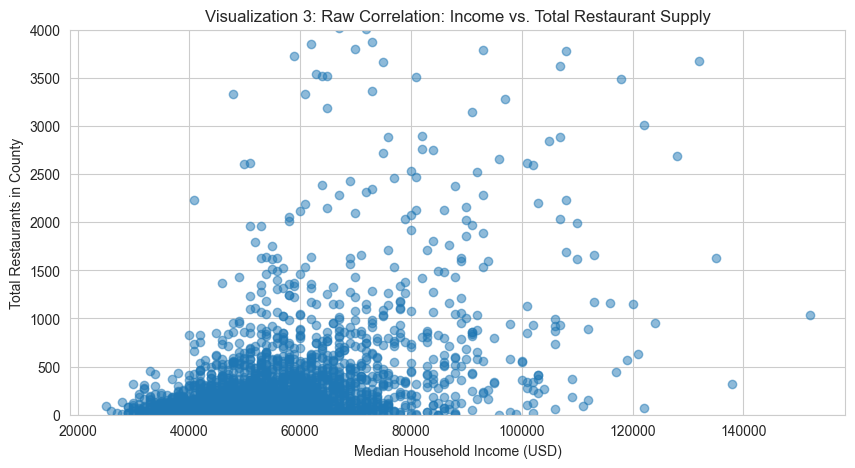

In [8]:
# Cell 7: Exploratory Data Analysis (EDA) on Raw Joined Data
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

# --- 1. Clean and Deduplicate Data for County-Level EDA ---
eda_cols = ["medianHouseholdIncome", "totalPopulation", "totalRestaurants", "Pizza", "MexicanRestaurants", "ChineseRestaurants", "AmericanRestaurants", "FastFoodRestaurants"]

def try_cast_double(c):
    # Use try_cast to safely convert strings ('NA') to numbers (NULL)
    return F.expr(f"try_cast(`{c}` as double)")

df_eda = df_final_joined
for c in eda_cols:
    if c in df_eda.columns:
        df_eda = df_eda.withColumn(c, try_cast_double(c))
    
# Filter out nulls and remove duplicates (using FIPS_Key) to get a county-level view.
df_eda_county_view = df_eda.select("FIPS_Key", *eda_cols).dropDuplicates().dropna()
df_eda_pd = df_eda_county_view.toPandas()


# --- VISUALIZATION 1: Distribution of Median Household Income ---
plt.figure(figsize=(10, 5))
sns.histplot(df_eda_pd["medianHouseholdIncome"], bins=50, kde=True)
plt.title("Visualization 1: Distribution of County-Level Median Household Income")
plt.xlabel("Median Household Income (USD)")
plt.ylabel("County Count")


# --- VISUALIZATION 2: Top 5 Average Restaurant Supply per County ---
top_cuisine_cols = ["Pizza", "MexicanRestaurants", "ChineseRestaurants", "AmericanRestaurants", "FastFoodRestaurants"]
mean_counts = df_eda_pd[top_cuisine_cols].mean().sort_values(ascending=False).reset_index()
mean_counts.columns = ['Cuisine', 'Average_Count']

plt.figure(figsize=(10, 5))
sns.barplot(x='Average_Count', y='Cuisine', data=mean_counts, palette="Spectral")
plt.title("Visualization 2: Average Restaurant Count per County (Top 5 Categories)")
plt.xlabel("Average Count per County")
plt.ylabel("Cuisine Type")


# --- VISUALIZATION 3: Income vs. Total Restaurant Supply (County Level) ---
plt.figure(figsize=(10, 5))
plt.scatter(df_eda_pd["medianHouseholdIncome"], df_eda_pd["totalRestaurants"], alpha=0.5)
plt.title("Visualization 3: Raw Correlation: Income vs. Total Restaurant Supply")
plt.xlabel("Median Household Income (USD)")
plt.ylabel("Total Restaurants in County")
plt.ylim(0, 4000)


# --- FINAL OUTPUT: Display all generated plots ---
print("Initial EDA on Raw Joined Data Complete. Displaying visualizations now.")
plt.show() 

In [9]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# 1. Define columns to keep
# These are the columns from the CSV that we want to analyze at the county level
cols_to_keep = [
    "FIPS_Key", 
    "countyStateName",
    "medianHouseholdIncome", 
    "totalPopulation", 
    "povertyPercent", 
    "obesityPercent", 
    "aged65AndOlder",
    "Pizza", 
    "MexicanRestaurants", 
    "ChineseRestaurants", 
    "CoffeeShops", 
    "FastFoodRestaurants",
    "AmericanRestaurants",
    "ItalianRestaurants",
    "totalRestaurants"
]

# 2. Extract unique County rows safely
# We use a loop to apply 'try_cast' which turns "NA" strings into NULLs instead of crashing
select_exprs = []
for c in cols_to_keep:
    if c in ["FIPS_Key", "countyStateName"]:
        select_exprs.append(F.col(c))
    else:
        # This handles the "NA" error by converting non-numbers to NULL safely
        select_exprs.append(F.expr(f"try_cast(`{c}` as double)").alias(c))

df_county_level = df_final_joined.select(*select_exprs).dropDuplicates(["FIPS_Key"])

# 3. Filter out invalid data (NULLs or essentially empty counties)
df_county_level = df_county_level.filter(
    (F.col("totalPopulation") > 20000) & 
    (F.col("medianHouseholdIncome") > 5000)
).fillna(0) # Fill null cuisine counts with 0 (safe after filtering for valid population)

print("County Level Data Prepared. Sample:")
df_county_level.show(5)

County Level Data Prepared. Sample:


+--------+---------------+---------------------+---------------+--------------+--------------+--------------+-----+------------------+------------------+-----------+-------------------+-------------------+------------------+----------------+
|FIPS_Key|countyStateName|medianHouseholdIncome|totalPopulation|povertyPercent|obesityPercent|aged65AndOlder|Pizza|MexicanRestaurants|ChineseRestaurants|CoffeeShops|FastFoodRestaurants|AmericanRestaurants|ItalianRestaurants|totalRestaurants|
+--------+---------------+---------------------+---------------+--------------+--------------+--------------+-----+------------------+------------------+-----------+-------------------+-------------------+------------------+----------------+
|   01001|"Autauga, (AL)"|              58000.0|        55380.0|          12.1|          32.7|          15.0| 19.0|              16.0|               7.0|        5.0|               48.0|               15.0|               4.0|           219.0|
|   01003|"Baldwin, (AL)"|      

## Phase 1: Market Segmentation (Clustering)
We use **K-Means Clustering** to group zip codes with similar demographic profiles. This allows us to compare "apples to apples"—ensuring that a rural county in Utah is not compared directly to downtown Manhattan.

**Feature Selection:**
* `population_density`: To distinguish urban vs. rural.
* `median_income`: To separate working-class vs. affluent areas.
* `bachelors_degree_percent`: A proxy for education/lifestyle preferences.

**Model Choice:**
We selected **K=4** based on the Silhouette Score, which identified four distinct market types:
1.  **Rural/Sparse** (Low density, variable income)
2.  **Suburban** (Moderate density, moderate income)
3.  **High Density/Urban** (High population, younger)
4.  **Affluent** (High income, high education)

In [10]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import log1p, col

# 1. Identify Features to Scale
features_to_scale = [
    "medianHouseholdIncome", 
    "totalPopulation", 
    "povertyPercent", 
    "obesityPercent", 
    "aged65AndOlder"
]

# 2. Log Transform (Log_Income, Log_Pop)
df_log = df_county_level
log_cols = []

print("Applying Log Transformation...")
for c in features_to_scale:
    log_col_name = f"Log_{c}"
    df_log = df_log.withColumn(log_col_name, log1p(col(c)))
    log_cols.append(log_col_name)

# 3. Vectorize
assembler = VectorAssembler(inputCols=log_cols, outputCol="features")
df_vectorized = assembler.transform(df_log)

# 4. Standard Scale (Z-Score)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)
scalerModel = scaler.fit(df_vectorized)
final_cluster_data = scalerModel.transform(df_vectorized)

print("Data Scaled and Ready for Clustering.")
final_cluster_data.select("countyStateName", "scaledFeatures").show(3, truncate=False)

Applying Log Transformation...


Data Scaled and Ready for Clustering.


+---------------+-----------------------------------------------------------------------------------------------+
|countyStateName|scaledFeatures                                                                                 |
+---------------+-----------------------------------------------------------------------------------------------+
|"Autauga, (AL)"|[45.43240073234774,10.116970570772946,7.1505646845167075,20.540243793264192,12.804261074315301]|
|"Baldwin, (AL)"|[45.57282492138069,11.364004233543232,6.690093628189523,20.071394451005546,14.060094750630746] |
|"Barbour, (AL)"|[43.456935642493896,9.393549590726282,9.271757262204916,21.853666234170063,13.741474563042315] |
+---------------+-----------------------------------------------------------------------------------------------+
only showing top 3 rows


Calculating Silhouette Scores for Counties...


k = 2, Silhouette Score = 0.4836


k = 3, Silhouette Score = 0.3559


k = 4, Silhouette Score = 0.3649


k = 5, Silhouette Score = 0.3722


k = 6, Silhouette Score = 0.3219


k = 7, Silhouette Score = 0.3488


k = 8, Silhouette Score = 0.3289


k = 9, Silhouette Score = 0.3063


k = 10, Silhouette Score = 0.2955


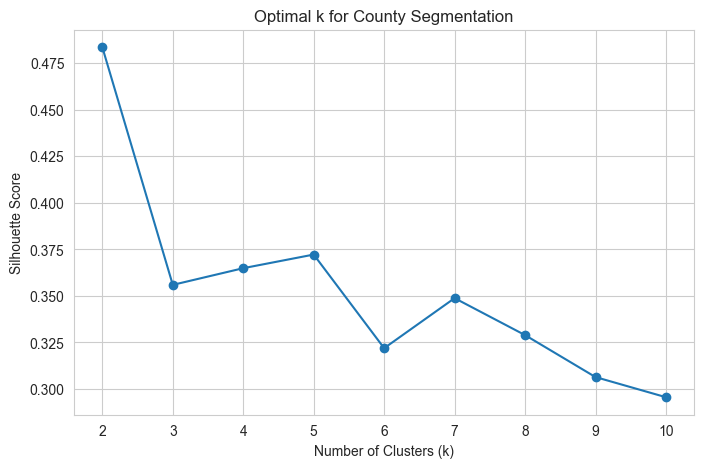

In [11]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

silhouette_scores = []
k_values = range(2, 11)

evaluator = ClusteringEvaluator(
    predictionCol='prediction', 
    featuresCol='scaledFeatures', \
    metricName='silhouette', 
    distanceMeasure='squaredEuclidean'
)

print("Calculating Silhouette Scores for Counties...")

for k in k_values:
    kmeans = KMeans(featuresCol='scaledFeatures', k=k, seed=42)
    model = kmeans.fit(final_cluster_data)
    predictions = model.transform(final_cluster_data)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Optimal k for County Segmentation')
plt.grid(True)
plt.show()

In [12]:
# Choose k=4 
BEST_K = 4

print(f"Training Final Model with k={BEST_K}...")

kmeans = KMeans(featuresCol='scaledFeatures', k=BEST_K, seed=42)
km_model = kmeans.fit(final_cluster_data)
df_clustered = km_model.transform(final_cluster_data)

# Rename prediction column
df_clustered = df_clustered.withColumnRenamed("prediction", "Cluster_ID")

# Show Cluster Sizes
print("Counties per Cluster:")
df_clustered.groupBy("Cluster_ID").count().orderBy("Cluster_ID").show()

# Show Centers
centers = km_model.clusterCenters()
print("Cluster Centers (Log Scale):")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

Training Final Model with k=4...


Counties per Cluster:


+----------+-----+
|Cluster_ID|count|
+----------+-----+
|         0|  473|
|         1|  539|
|         2|  242|
|         3|  566|
+----------+-----+

Cluster Centers (Log Scale):
Cluster 0: [45.63286674 10.88787925  7.18490977 20.69826031 12.58509229]
Cluster 1: [45.44692127  9.93231268  6.92218419 20.35199049 14.20913398]
Cluster 2: [47.04761967 11.73143917  5.99627543 19.22088751 12.65325583]
Cluster 3: [44.39567951  9.83140366  8.26133501 21.32878566 13.50835446]


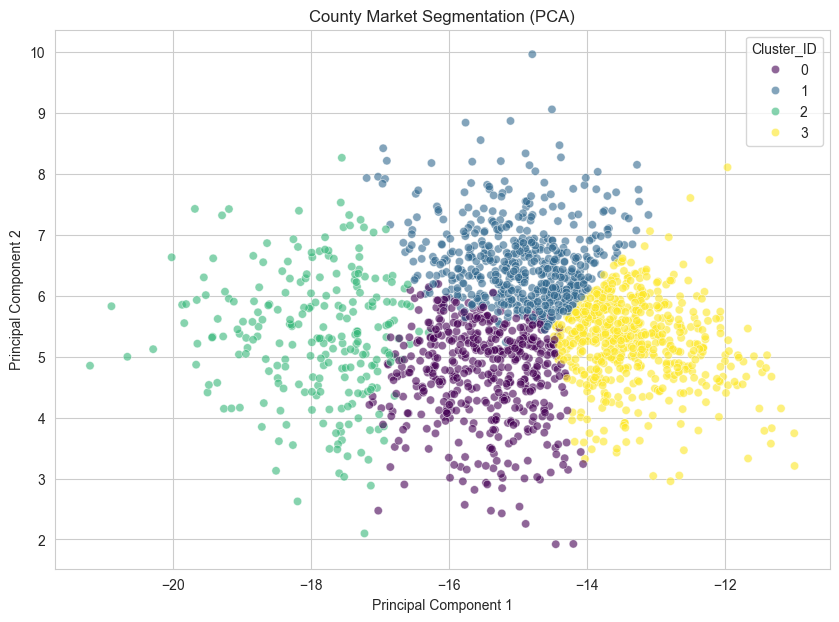

In [13]:
from pyspark.ml.feature import PCA
import pandas as pd
import seaborn as sns 

# 1. PCA to 2D
pca = PCA(k=2, inputCol="scaledFeatures", outputCol="pcaFeatures")
pca_model = pca.fit(df_clustered)
pca_result = pca_model.transform(df_clustered).select("pcaFeatures", "Cluster_ID")

# 2. To Pandas
pandas_df = pca_result.toPandas()
pandas_df['x'] = pandas_df['pcaFeatures'].apply(lambda v: float(v[0]))
pandas_df['y'] = pandas_df['pcaFeatures'].apply(lambda v: float(v[1]))

# 3. Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='x', y='y', 
    hue='Cluster_ID', 
    palette='viridis', 
    data=pandas_df, 
    alpha=0.6
)
plt.title(f'County Market Segmentation (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## Phase 2: Demand Prediction (Random Forest)
Now that we have demographic features, we train a **Random Forest Regressor** to predict the *expected* number of restaurants for a specific cuisine (e.g., Mexican, Pizza).

**Why Random Forest?**
* It handles non-linear relationships better than Linear Regression (e.g., restaurant density might plateau after a certain income level).
* It is robust to outliers, which is important given the variance in US Census data.

**Target Variable:** `restaurant_count_per_10k` (Normalized density)

In [14]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorAssembler

# 1. Inputs: Demographics + Cluster ID
reg_input_cols = features_to_scale + ["Cluster_ID"]
reg_assembler = VectorAssembler(inputCols=reg_input_cols, outputCol="reg_features")
df_reg_ready = reg_assembler.transform(df_clustered)

# 2. Split
train_data, test_data = df_reg_ready.randomSplit([0.7, 0.3], seed=42)

# 3. Analyze Specific Cuisines
target_cuisines = ["Pizza", "MexicanRestaurants", "CoffeeShops", "ChineseRestaurants"]
gap_results = []

for cuisine in target_cuisines:
    print(f"\n--- Analyzing Market Gap for: {cuisine} ---")
    
    # Target: Restaurants per 10k people
    train_data = train_data.withColumn("Target_Density", (F.col(cuisine) / (F.col("totalPopulation")+1)) * 10000)
    test_data = test_data.withColumn("Target_Density", (F.col(cuisine) / (F.col("totalPopulation")+1)) * 10000)
    
    # Train
    rf = RandomForestRegressor(featuresCol="reg_features", labelCol="Target_Density", numTrees=30)
    model = rf.fit(train_data)
    
    # Predict
    preds = model.transform(test_data)
    
    # Gap = Prediction (Demand) - Actual (Supply)
    preds = preds.withColumn("Gap", F.col("prediction") - F.col("Target_Density"))
    gap_results.append((cuisine, preds))

print("\nGap Analysis Complete.")


--- Analyzing Market Gap for: Pizza ---



--- Analyzing Market Gap for: MexicanRestaurants ---



--- Analyzing Market Gap for: CoffeeShops ---



--- Analyzing Market Gap for: ChineseRestaurants ---



Gap Analysis Complete.


## Phase 3: Gap Analysis & Results
We define a "Gap" as the difference between the **Predicted Demand** and the **Actual Supply**.

$$\text{Gap Score} = \text{Predicted Count} - \text{Actual Count}$$

* **Positive Gap (> 0):** The model predicts the area *should* support more restaurants than it currently has (Underserved).
* **Negative Gap (< 0):** The area has more restaurants than demographic models suggest (Oversaturated).

The table below displays the top zip codes with the highest "Underserved" scores, representing potential opportunities for new site selection.

In [15]:
for cuisine, df_res in gap_results:
    print(f"\n==========================================")
    print(f"TOP 5 UNDERSERVED COUNTIES FOR: {cuisine.upper()}")
    print(f"==========================================")
    
    df_res.select(
        "countyStateName",
        "Cluster_ID",
        F.format_number("medianHouseholdIncome", 0).alias("Income"),
        F.format_number("totalPopulation",2).alias("Population"),
        F.format_number("Target_Density", 2).alias("Actual_Density"),
        F.format_number("prediction", 2).alias("Predicted"),
        F.format_number("Gap", 2).alias("Opportunity_Gap")
    ).orderBy(F.col("Gap").desc()).show(5, truncate=False)


TOP 5 UNDERSERVED COUNTIES FOR: PIZZA


+------------------+----------+------+----------+--------------+---------+---------------+
|countyStateName   |Cluster_ID|Income|Population|Actual_Density|Predicted|Opportunity_Gap|
+------------------+----------+------+----------+--------------+---------+---------------+
|"Yankton, (SD)"   |1         |61,000|22,717.00 |0.00          |10.22    |10.22          |
|"Uinta, (WY)"     |0         |71,000|20,479.00 |1.95          |11.51    |9.56           |
|"Teton, (WY)"     |2         |99,000|23,280.00 |0.00          |8.94     |8.94           |
|"Hood River, (OR)"|1         |69,000|23,209.00 |0.00          |8.78     |8.78           |
|"Taylor, (WI)"    |1         |52,000|20,325.00 |0.98          |9.67     |8.69           |
+------------------+----------+------+----------+--------------+---------+---------------+
only showing top 5 rows

TOP 5 UNDERSERVED COUNTIES FOR: MEXICANRESTAURANTS


+----------------------------+----------+------+----------+--------------+---------+---------------+
|countyStateName             |Cluster_ID|Income|Population|Actual_Density|Predicted|Opportunity_Gap|
+----------------------------+----------+------+----------+--------------+---------+---------------+
|"Plaquemines, (LA)"         |0         |61,000|23,338.00 |0.00          |7.08     |7.08           |
|"St. John the Baptist, (LA)"|3         |55,000|43,242.00 |1.85          |8.86     |7.01           |
|"Dakota, (NE)"              |0         |61,000|20,173.00 |0.50          |7.38     |6.88           |
|"Texas, (OK)"               |0         |56,000|20,805.00 |0.48          |6.97     |6.49           |
|"Sanpete, (UT)"             |0         |55,000|29,850.00 |0.33          |6.35     |6.01           |
+----------------------------+----------+------+----------+--------------+---------+---------------+
only showing top 5 rows

TOP 5 UNDERSERVED COUNTIES FOR: COFFEESHOPS


+---------------+----------+------+----------+--------------+---------+---------------+
|countyStateName|Cluster_ID|Income|Population|Actual_Density|Predicted|Opportunity_Gap|
+---------------+----------+------+----------+--------------+---------+---------------+
|"Vilas, (WI)"  |1         |56,000|21,751.00 |1.84          |5.35     |3.51           |
|"Tyler, (TX)"  |3         |48,000|21,518.00 |0.00          |2.53     |2.53           |
|"Pacific, (WA)"|1         |51,000|21,688.00 |1.38          |3.87     |2.49           |
|"Nye, (NV)"    |1         |48,000|44,380.00 |0.23          |2.42     |2.20           |
|"Jay, (IN)"    |1         |49,000|20,840.00 |0.48          |2.62     |2.14           |
+---------------+----------+------+----------+--------------+---------+---------------+
only showing top 5 rows

TOP 5 UNDERSERVED COUNTIES FOR: CHINESERESTAURANTS


+--------------------+----------+-------+----------+--------------+---------+---------------+
|countyStateName     |Cluster_ID|Income |Population|Actual_Density|Predicted|Opportunity_Gap|
+--------------------+----------+-------+----------+--------------+---------+---------------+
|"Teton, (WY)"       |2         |99,000 |23,280.00 |0.00          |3.80     |3.80           |
|"Hood River, (OR)"  |1         |69,000 |23,209.00 |0.00          |2.65     |2.65           |
|"Douglas, (NV)"     |1         |76,000 |48,132.00 |0.83          |3.41     |2.58           |
|"Fairfax City, (VA)"|2         |106,000|23,531.00 |0.85          |3.40     |2.55           |
|"Uinta, (WY)"       |0         |71,000 |20,479.00 |0.98          |3.33     |2.36           |
+--------------------+----------+-------+----------+--------------+---------+---------------+
only showing top 5 rows


In [16]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F

print("Generating Diverse Location Recommendations (Best 2 of each Cluster) with refined filters...")

# Iterate through the results calculated in the previous cell
for cuisine, df_res in gap_results:
    print(f"\n===========================================================")
    print(f"   {cuisine.upper()} RECOMMENDATIONS BY MARKET TYPE (Pop > 50K, Actual Density > 0)")
    print(f"===========================================================")
    
    df_opportunities = df_res.filter(
        (F.col("Gap") > 0) & # Only positive gaps (predicted demand > actual supply)
        (F.col("totalPopulation") > 50000) & # Filter 1: Population greater than 50,000
        (F.col("Target_Density") > 0)        # Filter 2: Actual restaurant density is non-zero
    )

    # 2. Define Window to rank counties WITHIN each cluster
    windowSpec = Window.partitionBy("Cluster_ID").orderBy(F.col("Gap").desc())
    
    # 3. Add Rank column
    ranked = df_opportunities.withColumn("Rank", F.row_number().over(windowSpec))
    
    # 4. Filter for the top 2 in each cluster
    best_of_clusters = ranked.filter(F.col("Rank") <= 2)
    
    # 5. Display specific columns
    best_of_clusters.select(\
        "Cluster_ID", \
        F.col("Rank"),\
        F.col("countyStateName").alias("County"), \
        F.format_number("medianHouseholdIncome", 0).alias("Income"),\
        F.format_number("totalPopulation", 0).alias("Pop"),\
        F.format_number("Target_Density", 2).alias("Actual_Dens"),\
        F.format_number("prediction", 2).alias("Pred_Dens"),\
        F.format_number("Gap", 2).alias("Gap")\
    ).orderBy("Cluster_ID", "Rank").show(truncate=False)

Generating Diverse Location Recommendations (Best 2 of each Cluster) with refined filters...

   PIZZA RECOMMENDATIONS BY MARKET TYPE (Pop > 50K, Actual Density > 0)


+----------+----+-----------------+-------+-------+-----------+---------+----+
|Cluster_ID|Rank|County           |Income |Pop    |Actual_Dens|Pred_Dens|Gap |
+----------+----+-----------------+-------+-------+-----------+---------+----+
|0         |1   |"Tooele, (UT)"   |80,000 |67,397 |0.30       |6.45     |6.15|
|0         |2   |"Box Elder, (UT)"|69,000 |53,946 |1.67       |6.80     |5.13|
|1         |1   |"Lancaster, (SC)"|64,000 |92,308 |0.43       |5.24     |4.81|
|1         |2   |"Clallam, (WA)"  |58,000 |75,392 |1.59       |5.36     |3.77|
|2         |1   |"Calvert, (MD)"  |111,000|91,511 |0.44       |5.69     |5.25|
|2         |2   |"Sarpy, (NE)"    |84,000 |181,232|1.43       |4.40     |2.97|
|3         |1   |"Valencia, (NM)" |55,000 |76,027 |0.13       |4.83     |4.70|
|3         |2   |"Coos, (OR)"     |50,000 |63,686 |1.10       |5.60     |4.50|
+----------+----+-----------------+-------+-------+-----------+---------+----+


   MEXICANRESTAURANTS RECOMMENDATIONS BY MARKET TY

+----------+----+--------------------+-------+-------+-----------+---------+----+
|Cluster_ID|Rank|County              |Income |Pop    |Actual_Dens|Pred_Dens|Gap |
+----------+----+--------------------+-------+-------+-----------+---------+----+
|0         |1   |"St. Charles, (LA)" |72,000 |52,773 |1.52       |7.09     |5.58|
|0         |2   |"Pulaski, (MO)"     |56,000 |52,425 |2.10       |5.07     |2.97|
|1         |1   |"Winona, (MN)"      |64,000 |50,725 |0.79       |2.73     |1.94|
|1         |2   |"Indian River, (FL)"|61,000 |153,989|0.52       |2.44     |1.92|
|2         |1   |"Carver, (MN)"      |102,000|101,949|0.59       |3.41     |2.82|
|2         |2   |"Calvert, (MD)"     |111,000|91,511 |0.22       |2.70     |2.48|
|3         |1   |"Russell, (AL)"     |44,000 |57,952 |1.21       |3.94     |2.73|
|3         |2   |"Athens, (OH)"      |44,000 |65,917 |0.61       |2.95     |2.34|
+----------+----+--------------------+-------+-------+-----------+---------+----+


   COFFEESHOPS

+----------+----+-----------------+-------+-------+-----------+---------+----+
|Cluster_ID|Rank|County           |Income |Pop    |Actual_Dens|Pred_Dens|Gap |
+----------+----+-----------------+-------+-------+-----------+---------+----+
|0         |1   |"Tooele, (UT)"   |80,000 |67,397 |0.15       |1.63     |1.48|
|0         |2   |"Warren, (IA)"   |80,000 |50,076 |0.80       |1.95     |1.15|
|1         |1   |"Lancaster, (SC)"|64,000 |92,308 |0.11       |1.29     |1.19|
|1         |2   |"Pasco, (FL)"    |56,000 |524,602|0.29       |1.34     |1.06|
|2         |1   |"Oldham, (KY)"   |101,000|65,967 |0.30       |1.81     |1.51|
|2         |2   |"Fayette, (GA)"  |95,000 |112,303|0.27       |1.42     |1.15|
|3         |1   |"Jefferson, (TN)"|50,000 |53,679 |0.19       |1.81     |1.63|
|3         |2   |"Gila, (AZ)"     |46,000 |53,546 |0.93       |2.43     |1.49|
+----------+----+-----------------+-------+-------+-----------+---------+----+


   CHINESERESTAURANTS RECOMMENDATIONS BY MARKET TY

+----------+----+-------------------------+------+-------+-----------+---------+----+
|Cluster_ID|Rank|County                   |Income|Pop    |Actual_Dens|Pred_Dens|Gap |
+----------+----+-------------------------+------+-------+-----------+---------+----+
|0         |1   |"Matanuska-Susitna, (AK)"|76,000|105,369|0.09       |1.69     |1.60|
|0         |2   |"Scott, (KY)"            |75,000|54,667 |1.10       |2.53     |1.43|
|1         |1   |"Yavapai, (AZ)"          |54,000|228,067|0.13       |1.11     |0.98|
|1         |2   |"Nevada, (CA)"           |70,000|99,244 |0.60       |1.54     |0.93|
|2         |1   |"Sarpy, (NE)"            |84,000|181,232|0.22       |1.59     |1.37|
|2         |2   |"Deschutes, (OR)"        |72,000|186,251|0.21       |1.16     |0.95|
|3         |1   |"St. Mary, (LA)"         |41,000|50,968 |0.20       |1.36     |1.17|
|3         |2   |"Henderson, (TX)"        |50,000|81,070 |0.12       |1.29     |1.16|
+----------+----+-------------------------+------+----

# Plots for presentation/report

--- Model Accuracy for Pizza ---
RMSE: 3.9512 (Standard Deviation of the residuals)
MAE:  2.8377 (Average absolute error in density)


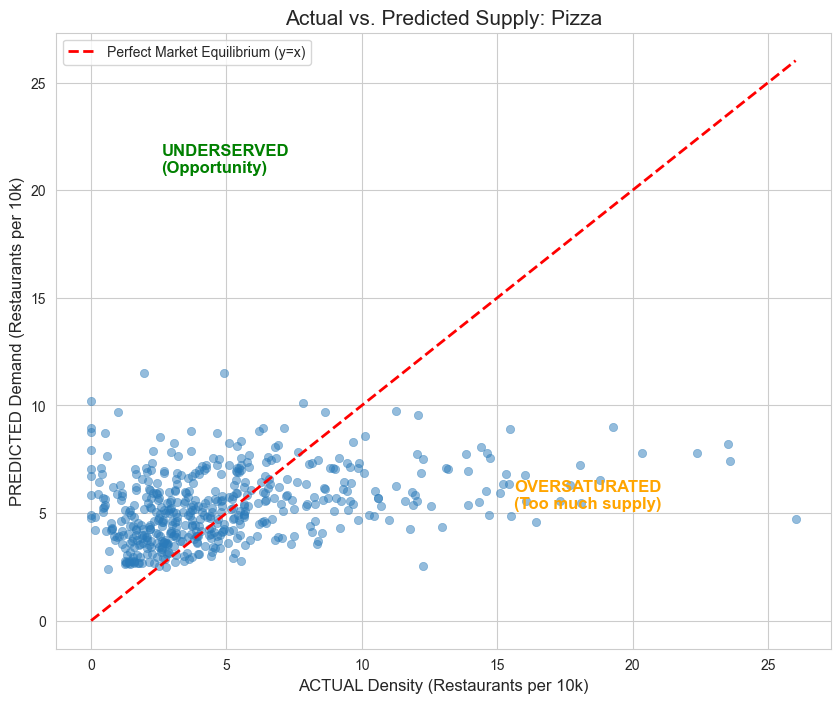

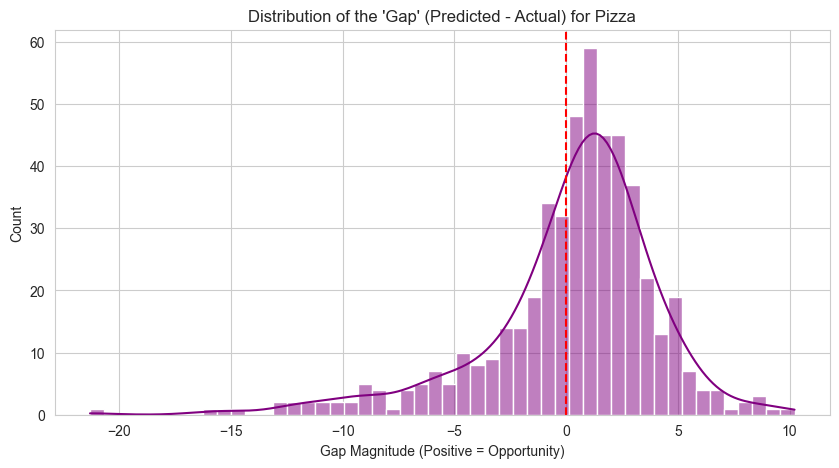

In [17]:
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Select one cuisine to visualize
target_cuisine_name = "Pizza" 

# Find the dataframe for this cuisine from your gap_results list
current_preds = next(item[1] for item in gap_results if item[0] == target_cuisine_name)

# --- 1. QUANTITATIVE METRICS (Sanity Check) ---
# RMSE: How far off is the prediction on average?
rmse_evaluator = RegressionEvaluator(labelCol="Target_Density", predictionCol="prediction", metricName="rmse")
mae_evaluator = RegressionEvaluator(labelCol="Target_Density", predictionCol="prediction", metricName="mae")

rmse = rmse_evaluator.evaluate(current_preds)
mae = mae_evaluator.evaluate(current_preds)

print(f"--- Model Accuracy for {target_cuisine_name} ---")
print(f"RMSE: {rmse:.4f} (Standard Deviation of the residuals)")
print(f"MAE:  {mae:.4f} (Average absolute error in density)")

# --- 2. VISUALIZATION (Actual vs. Predicted) ---
pdf = current_preds.select("Target_Density", "prediction", "Gap", "countyStateName").toPandas()

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# Create the Scatter Plot
sns.scatterplot(
    x="Target_Density", 
    y="prediction", 
    data=pdf, 
    alpha=0.5, 
    edgecolor=None,
    color="#2b7bba"
)

# Add the "Identity Line" (y = x)
# Points ON this line mean Supply exactly matches Predicted Demand
max_val = max(pdf["Target_Density"].max(), pdf["prediction"].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Market Equilibrium (y=x)')

plt.title(f"Actual vs. Predicted Supply: {target_cuisine_name}", fontsize=15)
plt.xlabel("ACTUAL Density (Restaurants per 10k)", fontsize=12)
plt.ylabel("PREDICTED Demand (Restaurants per 10k)", fontsize=12)
plt.legend()

# Annotate the "Zones"
plt.text(max_val*0.1, max_val*0.8, "UNDERSERVED\n(Opportunity)", color='green', fontsize=12, fontweight='bold')
plt.text(max_val*0.6, max_val*0.2, "OVERSATURATED\n(Too much supply)", color='orange', fontsize=12, fontweight='bold')

plt.show()

# --- 3. RESIDUAL DISTRIBUTION ---
plt.figure(figsize=(10, 5))
sns.histplot(pdf["Gap"], kde=True, color="purple", bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.title(f"Distribution of the 'Gap' (Predicted - Actual) for {target_cuisine_name}")
plt.xlabel("Gap Magnitude (Positive = Opportunity)")
plt.show()